In [11]:
import pandas as pd
from pymatgen.core.structure import Structure
import matgl
import os
import torch

def load_predict_and_save(csv_path, model_name, output_path, base_path):
    # Load the dataframe
    df = pd.read_csv(csv_path)
    
    # Load the proxy model
    model = matgl.load_model(model_name)
    
    # Function to predict band gap
    def predict_band_gap(cif_path):
        full_path = os.path.join(base_path, cif_path)
        try:
            structure = Structure.from_file(full_path)
            # PBE method corresponds to index 0
            prediction = model.predict_structure(structure, state_attr=torch.tensor([0], dtype=torch.long))
            return prediction.item()  # Convert from tensor to scalar
        except FileNotFoundError:
            print(f"File not found: {full_path}")
            return None
        except Exception as e:
            print(f"Error processing {full_path}: {str(e)}")
            return None
    
    # Apply prediction to each row
    df['predicted_band_gap'] = df['CIF Path'].apply(predict_band_gap)
    
    # Save the updated dataframe
    df.to_csv(output_path, index=False)
    print(f"Updated dataframe saved to {output_path}")

# Example usage
base_path = "/scratch/harsha.vasamsetti/harsha.vasamsetti/final-code-xval-clone-band"
csv_path = os.path.join(base_path, 'sample/output_structures/reconstructed_sequences_with_properties_1.csv')
model_name = "MEGNet-MP-2019.4.1-BandGap-mfi"
output_path = 'reconstructed_sequences_with_predictions.csv'

load_predict_and_save(csv_path, model_name, output_path, base_path)

# Display the first few rows of the result
result_df = pd.read_csv(output_path)
print(result_df.head())

/home2/harsha.vasamsetti/miniconda3/envs/slices/lib/python3.9/site-packages/matgl/utils/io.py:126: UserWarning: Incompatible model version detected! The code will continue to load the model but it is recommended that you provide a path to an updated model, increment your @model_version in model.json if you are confident that the changes are not problematic, or clear your ~/.matgl cache using `python -c "import matgl; matgl.clear_cache()"`
  _check_ver(cls_, v)  # Check version of any subclasses too.
/home2/harsha.vasamsetti/miniconda3/envs/slices/lib/python3.9/site-packages/pymatgen/io/cif.py:1221: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


Updated dataframe saved to reconstructed_sequences_with_predictions.csv
   band_gap                                             SLICES  \
0       0.0  Ta Be Be Ru 0 2 - - - 0 2 - - o 0 2 o - - 0 2 ...   
1       0.0  Co Co Cu Cu As As 0 4 - - o 0 4 - o o 0 4 o - ...   
2       0.0  Lu Lu Ni Ni Sb Sb Sb Sb 0 6 - o o 0 6 - + o 0 ...   
3       0.0  Li Mg Ge Ge 0 3 o - - 0 3 o o o 0 3 + - o 0 3 ...   
4       0.0  Nd Nd Tl Tl Sn Sn Sn 0 5 - o o 0 5 - + o 0 5 o...   

                                   CIF Path  predicted_band_gap  
0  sample/output_structures/cif_files/0.cif           -0.012725  
1  sample/output_structures/cif_files/1.cif           -0.005846  
2  sample/output_structures/cif_files/2.cif           -0.007991  
3  sample/output_structures/cif_files/3.cif           -0.008786  
4  sample/output_structures/cif_files/4.cif           -0.007262  


In [5]:
pd.read_csv("/scratch/harsha.vasamsetti/reconstructed_sequences_with_predictions.csv").head()

,formation_energy_per_atom,SLICES,CIF Path,predicted_formation_energy
0,0.0,Ca Ca Ca Y 0 3 - - o 0 3 - o o 0 3 o - o 0 3 o...,sample/output_structures/cif_files/0.cif,tensor(0.1116)
1,0.0,Pm Ho Ho Ho 0 1 o - - 0 1 o o o 0 1 + - o 0 1 ...,sample/output_structures/cif_files/1.cif,tensor(0.0242)
2,0.0,Mn W 0 1 - - - 0 1 - - o 0 1 - o - 0 1 - o o 0...,sample/output_structures/cif_files/3.cif,tensor(0.1185)
3,0.0,La La La La Mg Mg 0 1 o - o 0 1 o - + 0 1 o o ...,sample/output_structures/cif_files/4.cif,tensor(0.0083)
4,0.0,Cr Re Re Re 0 3 - - - 0 3 - - o 0 3 o - - 0 3 ...,sample/output_structures/cif_files/5.cif,tensor(0.3357)


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


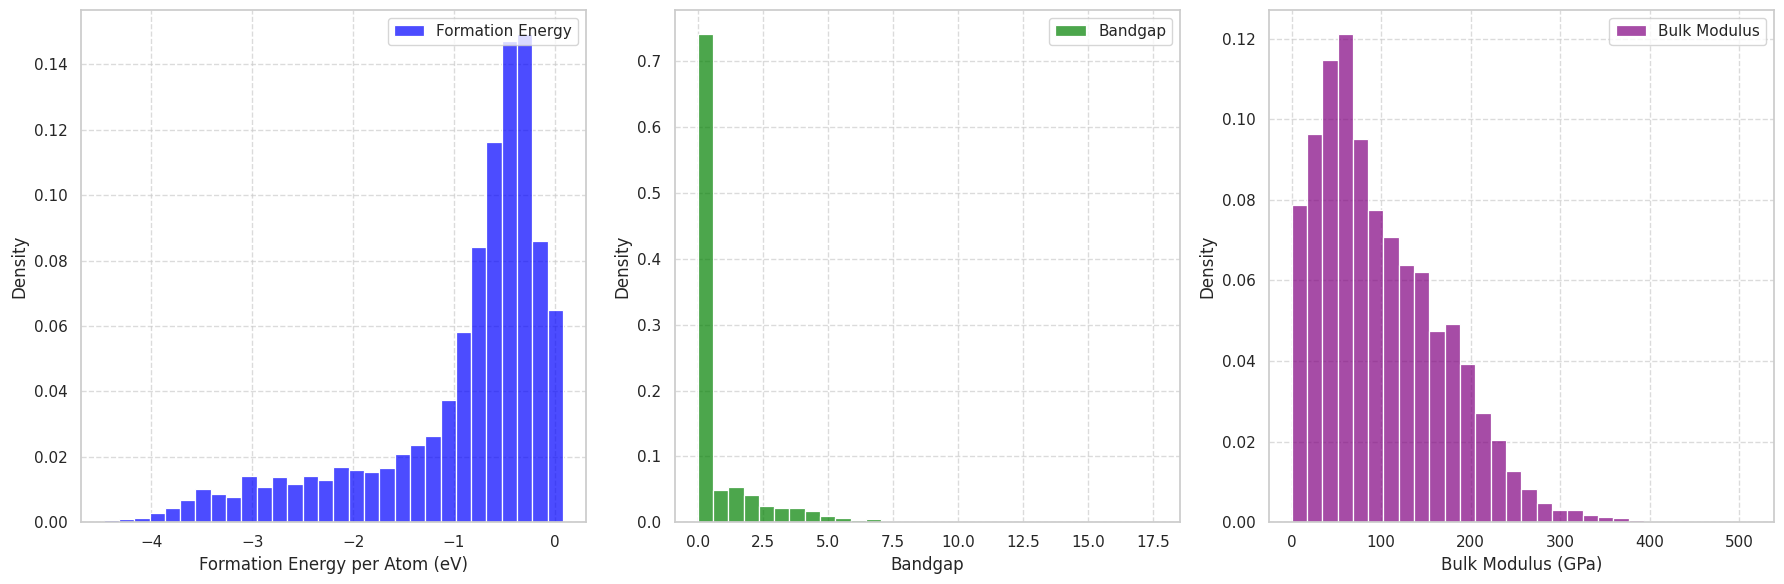

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your original dataset
file_path_1 = "/scratch/harsha.vasamsetti/scratch/harsha.vasamsetti/harsha.vasamsetti/final-code-xval-clone-form/dataset/mp_20_with_slices.csv"
df = pd.read_csv(file_path_1)

# Load the second dataset for Bulk Modulus
file_path_2 = "/scratch/harsha.vasamsetti/scratch/harsha.vasamsetti/harsha.vasamsetti/final-code-xval-clone-form-bulk/dataset/bulk_modulus_with_formation.csv"  
bulk_modulus_df = pd.read_csv(file_path_2)

# Merge datasets on a common key (assuming 'material_id' is the common column)
merged_df = pd.merge(df, bulk_modulus_df, left_on='material_id', right_on='Material ID')

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Set up the figure for better layout
plt.figure(figsize=(18, 6))  # Larger width to accommodate 3 plots

# Histogram for Formation Energy Per Atom with probability density
plt.subplot(1, 3, 1)
sns.histplot(merged_df['formation_energy_per_atom'], bins=30, kde=False, stat="probability", color="blue", label='Formation Energy', alpha=0.7)
plt.xlabel('Formation Energy per Atom (eV)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram for Band Gap with probability density
plt.subplot(1, 3, 2)
sns.histplot(merged_df['band_gap'], bins=30, kde=False, stat="probability", color="green", label='Bandgap', alpha=0.7)
plt.xlabel('Bandgap', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram for Bulk Modulus with probability density (from the second dataset)
plt.subplot(1, 3, 3)
sns.histplot(merged_df['Bulk Modulus (CSV)'], bins=30, kde=False, stat="probability", color="purple", label='Bulk Modulus', alpha=0.7)
plt.xlabel('Bulk Modulus (GPa)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout for better spacing between plots
plt.tight_layout()

# Save the figure as a PDF
# Uncomment the line below to save the figure as a PDF
plt.savefig("histogram_plots_formation_energy_bandgap_bulk_modulus.pdf", format="pdf", bbox_inches="tight")

# Show the plots
plt.show()
